<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 2
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
MC integrals and random walks
</h2>

<p style="color: blue; font-size: 25px; font-weight: bold;"> EXERCISE 2.1: Monte Carlo Integration </p>

Suppose to evaluate the one-dimensional integral
$$
I=\int_a^b f(x),dx.
$$
It can be introduced a probability density function $p(x)$ such that
$$
p(x)\ge0 \qquad \forall x\in[a,b], \qquad \int_a^b p(x),dx=1.
$$
The integral can then be rewritten as
$$
I=\int_a^b dx,f(x)=\int_a^b dx,p(x)\frac{f(x)}{p(x)}=\int_a^b dx,p(x),g(x)=\langle g\rangle,
$$
where $g(x)=\frac{f(x)}{p(x)}.$
Therefore, if random numbers can be sampled according to the probability density $p(x)$, the integral can be estimated through the arithmetic average
$$
G_N=\frac{1}{N}\sum_{i=1}^{N}g(x_i),
$$
so that
$$
I=G_N\pm\sigma_{G_N},
$$
with
$$
\sigma_{G_N}=\frac{\sigma_I}{\sqrt{N}}.
$$
The main advantage of the Monte Carlo method is that its computational cost does not depend on the dimensionality of the integration domain. While deterministic quadrature methods typically require a computational effort that scales as
$$
\left(\frac{c}{\varepsilon}\right)^{d/k},
$$

where (d) is the dimension of the problem, the MC method does not have dipendece on dimensionality, in fact
$$
\left(\frac{\sigma_I}{\varepsilon}\right)^2,
$$

## Importance Sampling

**How should the probability density $p(x)$ be to best perform on the integral?**

The variance of the MC estimator depends on the choice of the sampling distribution. By minimizing this variance, one finds that the optimal probability density is
$$
d_{\mathrm{opt}}(x)=\frac{f(x)}{I}.
$$
With this choice,
$$
g(x)=\frac{f(x)}{p_{\mathrm{opt}}(x)}=I,
$$
and so $G_N=I$, i.e the estimator exhibits zero variance and the integral is obtained exactly after a single sample.

Of course, this ideal sampling distribution cannot be used in practice, since it requires the knowledge of the integral (I), which is precisely the quantity we wish to compute. But, from the previous analysis one can see that the best pdf to be used is proportional to the integrand. For this reason, the idea of **importance sampling** is to choose a probability density that resembles the integrand as closely as possible while remaining non-negative, easy to normalize and sample. In practice, simple analytical approximations, such as low-order Taylor expansions, are often employed.

In particular, for this exercise where the integral is
$$
I=\int_0^1\frac{\pi}{2}\cos\big({\frac{\pi}{2}x}\big)=1,
$$
it is convenient to choose the Taylor expansion centered in x=1.
$$
cos\big({\frac{\pi}{2}x}\big)\simeq\frac{\pi}{2}(1-x)\\
$$
This choice rely on the fact that the pdf taken has the same behavior at the endpoints of the interval and is always non-negative in the interval.
Normalizaion requires that the complete density is $d(x)=2(1-x)$.
So, one sample points from this distribution, via the cumulative function method, and then compute the mean of
$$
\frac{\pi cos\big(\frac{\pi x}{2})}{4(1-x)}
$$
always using data-blocking.
In particular the code use a number of blocks equals to $100$ and a number of total MC step about $10^5$. It is shown a comparison between results obtained with uniform sampling, importance sampling, and exponential sampling.

In [1]:
import numpy as np

data_uni = np.loadtxt("./OUTPUT/uniform_sampling.out", skiprows=1)
data_impo = np.loadtxt("./OUTPUT/importance_sampling.out", skiprows=1)
data_exp = np.loadtxt("./OUTPUT/expo_sampling.out", skiprows=1)

In [2]:
N = data_uni[:, 0]
I_uni = data_uni[:, 1]
err_uni = data_uni[:, 2]

I_impo= data_impo[:, 1]
err_impo = data_impo[:, 2]

I_exp = data_exp[:, 1]
err_exp = data_exp[:, 2]

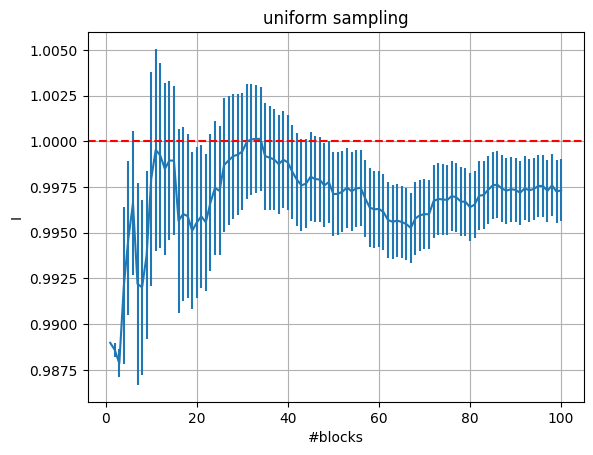

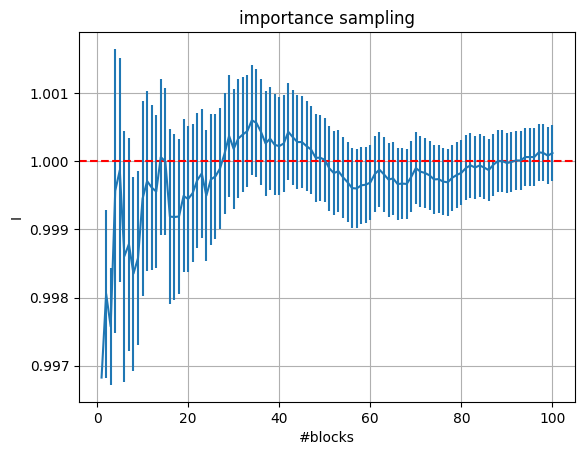

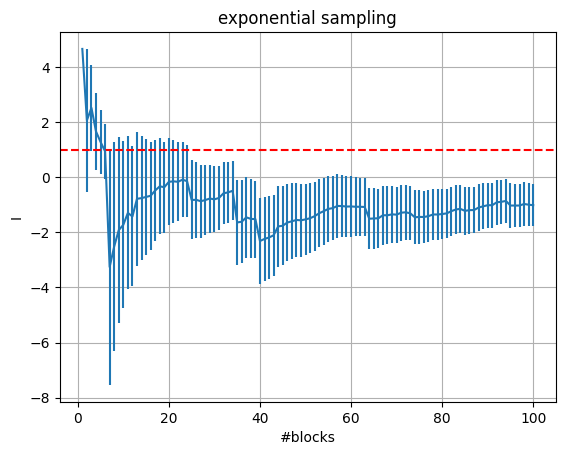

In [3]:
import matplotlib.pyplot as plt

plt.errorbar(N, I_uni, yerr=err_uni)
plt.axhline(1, ls='--', color='r', label='Exact')
plt.xlabel("#blocks")
plt.ylabel("I")
plt.grid(True)
plt.title("uniform sampling")
plt.show()

plt.errorbar(N, I_impo, yerr=err_impo)
plt.axhline(1, ls='--', color='r', label='Exact')
plt.xlabel("#blocks")
plt.ylabel("I")
plt.grid(True)
plt.title("importance sampling")
plt.show()

plt.errorbar(N, I_exp, yerr=err_exp)
plt.axhline(1, ls='--', color='r', label='Exact')
plt.xlabel("#blocks")
plt.ylabel("I")
plt.grid(True)
plt.title("exponential sampling")
plt.show()

<p style="color: blue; font-size: 25px; font-weight: bold;">
EXERCISE 2.2: Random Walks
</p>

In this section, we analyze random walks, namely stochastic processes in which, at each time step, a walker performs a displacement in a randomly chosen direction. Two different models are considered: a **discrete random walk**, where each step is restricted to one of the coordinate axes of a cubic lattice, and a **continuous random walk**, where the particle can move in any direction in three-dimensional space.

From a mathematical point of view, a random walk is a **Markov chain**, meaning that the probability distribution of the next step depends only on the current state of the system and not on its previous history.

For the discrete random walk, one of the three Cartesian axes is first selected at random. A second random number is then generated to determine whether the displacement of length (a) is performed in the positive or negative direction along the chosen axis.

For the continuous random walk, the step length is kept fixed at (a), while the direction is chosen uniformly over the surface of a sphere. This is achieved by generating the spherical angles
$$
\theta\in[0,\pi], \qquad\phi\in[0,2\pi],
$$
which uniquely determine the direction of the displacement.

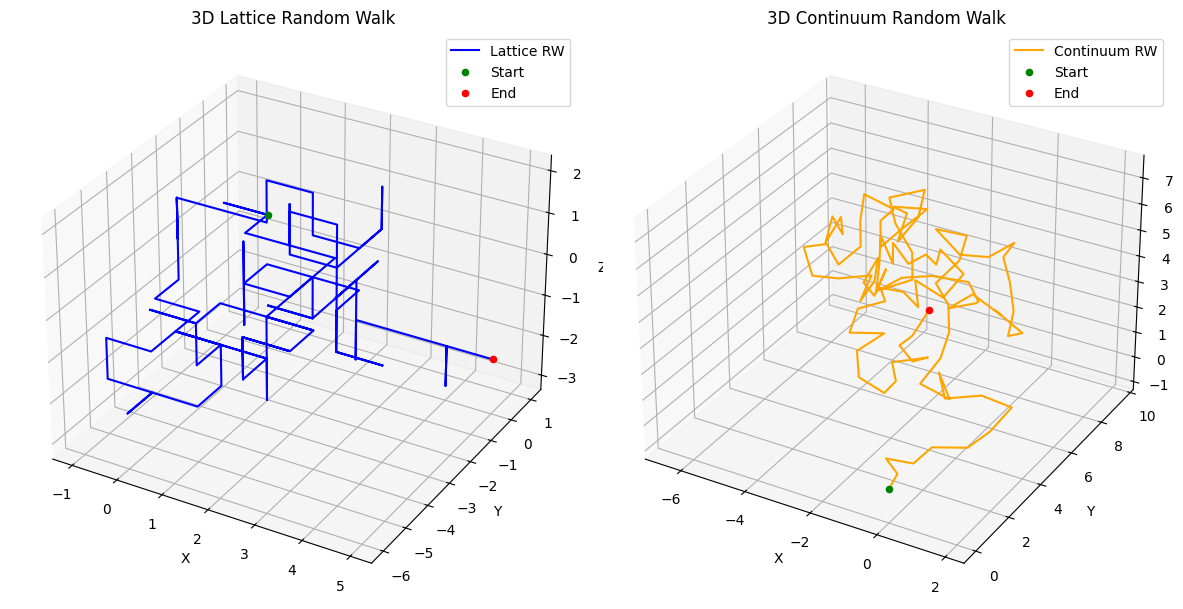

In [4]:
from mpl_toolkits.mplot3d import Axes3D

data1 = np.loadtxt("./OUTPUT/coord_lattice.xyz", skiprows=1) # lattice
x1, y1, z1 = data1[:, 0], data1[:, 1], data1[:, 2]

data2 = np.loadtxt("./OUTPUT/coord_continuum.xyz")
x2, y2, z2 = data2[:, 0], data2[:, 1], data2[:, 2]

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x1, y1, z1, color='b', label='Lattice RW')
ax1.scatter(x1[0], y1[0], z1[0], color='green', label='Start')
ax1.scatter(x1[-1], y1[-1], z1[-1], color='red', label='End')
ax1.set_title('3D Lattice Random Walk')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(x2, y2, z2, color='orange', label='Continuum RW')
ax2.scatter(x2[0], y2[0], z2[0], color='green', label='Start')
ax2.scatter(x2[-1], y2[-1], z2[-1], color='red', label='End')
ax2.set_title('3D Continuum Random Walk')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend()
plt.tight_layout()
plt.show()

### Root Mean Square Displacement

The aim of this analysis is to verify how the average mean square displacement (RMSD) $\sqrt{\langle |\mathbf{r}_N|^2\rangle}$ scales with the number of steps (N). Diffusion theory predicts that this quantity follows the law
$$
\sqrt{\langle |\mathbf{r}_N|^2\rangle}\propto\sqrt{N},
$$
which is the characteristic behavior of a diffusive process.

As in the previous exercises, the statistical analysis is performed using the data blocking technique. During each simulation, the value of the root mean square displacement is computed for every time step and stored in an Armadillo vector. At the end of each block, the vector contains the estimate of the root mean square displacement for every step of the random walk. These block estimates are then averaged over all blocks, and the corresponding statistical uncertainties are evaluated using the standard data-blocking procedure.

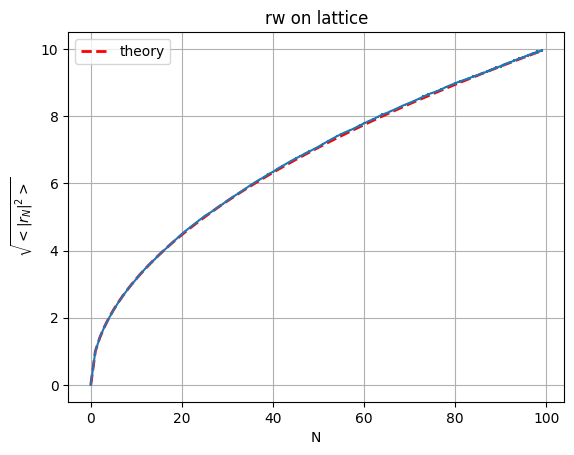

In [5]:
dat = np.loadtxt("./OUTPUT/rw_lattice_dist.out")
i = dat[:, 0]
rmsd = dat[:, 1]
err_rmsd = dat[:, 2]

k=1
y_theory = k*np.sqrt(i)

plt.plot(i, y_theory, color='r', lw=2, ls='--', label='theory')
plt.errorbar(i, rmsd, yerr=err_rmsd)
plt.xlabel("N")
plt.ylabel(r"$\sqrt{<|r_N|^2>}$")
plt.grid(True)
plt.legend()
plt.title("rw on lattice")
plt.show()

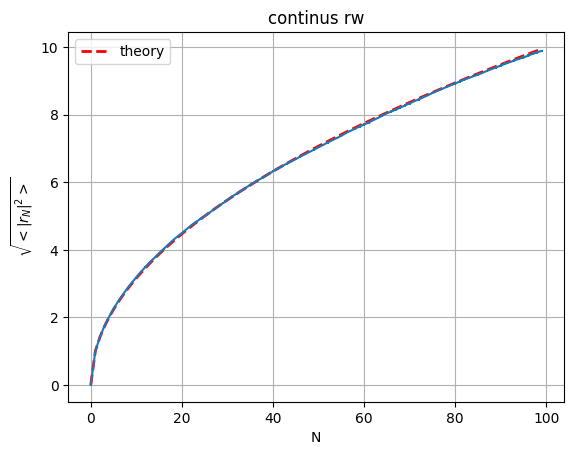

In [6]:
dat = np.loadtxt("./OUTPUT/rw_continuum_dist.out")
i = dat[:, 0]
rmsd = dat[:, 1]
err_rmsd = dat[:, 2]

plt.plot(i, y_theory, color='r', lw=2, ls='--', label='theory')
plt.errorbar(i, rmsd, yerr=err_rmsd)
plt.xlabel("N")
plt.ylabel(r"$\sqrt{<|r_N|^2>}$")
plt.grid(True)
plt.legend()
plt.title("continus rw")
plt.show()